In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "final.csv"   # change if needed
df = pd.read_csv(file_path)

# Remove index-like column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (93, 147)


,AXF Number,Core used,Amount of Core Used (g),UV used,Amount of UV Used (g),Emulsion viscosity (cP),Emulsion Gear Pump used,Single Emulsion (SE) Number,Vessel Used,Impellor Used,...,Agisyn 008,GC1000Z,OG name,NaCl_y,Glycerol,PDO_y,MPG,Sugar,PVA (10% in water),Outer_water
0,AXF0119,BNC00041,1500.0,BNU00059,3500.0,520.8,P23,SE014,5L Jug,Impellorpellor,...,0.0,0.0,AXF-1 outer,7,38,0.0,0.0,0,2.25,52.75
1,AXF0128,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,0.0,0.0,AXF-1 outer,7,38,0.0,0.0,0,2.25,52.75
2,AXF0129,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,0.0,0.0,AXF-1 outer,7,38,0.0,0.0,0,2.25,52.75
3,AXF0130,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,0.0,0.0,AXF-1 outer,7,38,0.0,0.0,0,2.25,52.75
4,AXF0130,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,0.0,0.0,AXF-1 outer,7,38,0.0,0.0,0,2.25,52.75



Columns:
['AXF Number', 'Core used', 'Amount of Core Used (g)', 'UV used', 'Amount of UV Used (g)', 'Emulsion viscosity (cP)', 'Emulsion Gear Pump used', 'Single Emulsion (SE) Number', 'Vessel Used', 'Impellor Used', 'Mass of emulsion used / g', 'Impellor Speed (rpm)', 'Core Loading (%)', 'Outer used', 'Outer Gear Pump Used', 'Dispersed Flow Rate (mL/min)', 'Continuous Flow Rate (mL/min)', 'Flow Rate Ratio', 'Cure Rig Used', 'Membrane Used (µm)', 'Insert used (mm)', 'Length of curing tubing (m)', 'Temperature of Outer Phase at end of experiment / C', 'UV Power (J s-1)', 'Curing Energy (kJ g-1)', '% dry after 24h in humidity', '% dry after 2 days in humidity chamber', 'QC Pass/Fail?', 'Core_formulation', 'UV_formulation', 'Outer_formulation', 'Klucel E', 'Klucel ELF ', 'Nisso 40 K ', 'Nisso 100 K ', 'Hyd HPC unknown MW', 'Hyd HPC 7k', 'Hyd HPC 15k', 'Hyd HPC 20k', 'Hyd KE HPC 9k', 'Hyd KE HPC 5k', 'NaCl_x', 'CaCl2', 'PDO_x', 'Glycerol ', '1,5-PDO', 'MPG ', 'C12E6', 'Core_water', 'Go Wa

## Define key columns and success criteria

The target is `% dry ≤ 20`.

Success is calculated for:
- `% dry after 24h in humidity`
- `% dry after 2 days in humidity chamber`

A row is considered fully successful only if both conditions are met.

In [43]:
# Key columns
batch_col = "AXF Number"
core_col = "Core used"
uv_col = "UV used"
dry_24_col = "% dry after 24h in humidity"
dry_2d_col = "% dry after 2 days in humidity chamber"

# Success flags
df["Success_24h"] = df[dry_24_col] <= 20
df["Success_2days"] = df[dry_2d_col] <= 20
df["Success_Both"] = df["Success_24h"] & df["Success_2days"]

print("24h success rate: {:.1f}%".format(df["Success_24h"].mean() * 100))
print("2-day success rate: {:.1f}%".format(df["Success_2days"].mean() * 100))
print("Success on both: {:.1f}%".format(df["Success_Both"].mean() * 100))

24h success rate: 33.3%
2-day success rate: 22.6%
Success on both: 22.6%


## Summary of % dry values

This section gives an overview of the `% dry` distributions for both humidity measurements.

In [44]:
display(df[[dry_24_col, dry_2d_col]].describe())

,% dry after 24h in humidity,% dry after 2 days in humidity chamber
count,93.000000,93.000000
mean,48.569892,58.440860
std,33.989896,34.357286
min,2.000000,5.000000
25%,20.000000,25.000000
50%,40.000000,50.000000
75%,85.000000,100.000000
max,100.000000,100.000000


## Best individual batches

These are the rows with the lowest `% dry` values, which are the most successful outcomes in the dataset.

In [45]:
best_rows = df[[batch_col, core_col, uv_col, dry_24_col, dry_2d_col, "Success_Both"]].copy()
best_rows = best_rows.sort_values([dry_24_col, dry_2d_col], ascending=True)

display(best_rows.head(20))

,AXF Number,Core used,UV used,% dry after 24h in humidity,% dry after 2 days in humidity chamber,Success_Both
3,AXF0130,BNC00044,BNU00068,2.0,5.0,True
4,AXF0130,BNC00044,BNU00068,5.0,5.0,True
8,AXF0134,BNC00044,BNU00068,5.0,15.0,True
24,AXF0166,BNC00045,BNU00074,5.0,15.0,True
9,AXF0136,BNC00044,BNU00068,10.0,10.0,True
35,AXF0181,BNC00046,BNU00074,10.0,10.0,True
42,AXF0199,BNC00047,BNU00077,10.0,10.0,True
45,AXF0203,BNC00045,BNU00075,10.0,10.0,True
46,AXF0204,BNC00045,BNU00075,10.0,10.0,True
47,AXF0205,BNC00045,BNU00075,10.0,10.0,True


## Successful batches only

This table shows only the batches that meet the target for both `% dry` measurements.

In [46]:
successful_rows = df[df["Success_Both"]].copy()

success_cols = [
    batch_col, core_col, uv_col,
    "Core_formulation", "UV_formulation", "Outer_formulation",
    dry_24_col, dry_2d_col
]

success_cols = [c for c in success_cols if c in df.columns]

display(successful_rows[success_cols].sort_values([dry_24_col, dry_2d_col]))

,AXF Number,Core used,UV used,Core_formulation,UV_formulation,Outer_formulation,% dry after 24h in humidity,% dry after 2 days in humidity chamber
3,AXF0130,BNC00044,BNU00068,RAD-C-0001,AUF110,2.25/38G/7,2.0,5.0
4,AXF0130,BNC00044,BNU00068,RAD-C-0001,AUF110,2.25/38G/7,5.0,5.0
8,AXF0134,BNC00044,BNU00068,RAD-C-0001,AUF110,2.25/38G/7,5.0,15.0
24,AXF0166,BNC00045,BNU00074,RAD-C-0001,AUF076,2.25/38G/7,5.0,15.0
9,AXF0136,BNC00044,BNU00068,RAD-C-0001,AUF110,2.25/38G/7,10.0,10.0
35,AXF0181,BNC00046,BNU00074,RAD-C-0002,AUF076,2.25/38G/7,10.0,10.0
42,AXF0199,BNC00047,BNU00077,RAD-C-0001,AUF076,2.25/38G/7,10.0,10.0
45,AXF0203,BNC00045,BNU00075,RAD-C-0001,AUF110,2.25/38G/7,10.0,10.0
46,AXF0204,BNC00045,BNU00075,RAD-C-0001,AUF110,2.25/38G/7,10.0,10.0
47,AXF0205,BNC00045,BNU00075,RAD-C-0001,AUF110,2.25/38G/7,10.0,10.0


## Batch-level summary

Some AXF batch numbers may appear more than once, so this section summarises performance by batch.

In [47]:
batch_summary = (
    df.groupby(batch_col)
      .agg(
          rows=(batch_col, "size"),
          core_used=(core_col, lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
          uv_used=(uv_col, lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]),
          mean_dry_24h=(dry_24_col, "mean"),
          mean_dry_2days=(dry_2d_col, "mean"),
          min_dry_24h=(dry_24_col, "min"),
          min_dry_2days=(dry_2d_col, "min"),
          success_rate_both=("Success_Both", "mean")
      )
      .reset_index()
)

batch_summary["success_rate_both"] *= 100
batch_summary = batch_summary.sort_values(
    ["success_rate_both", "mean_dry_24h", "mean_dry_2days"],
    ascending=[False, True, True]
)

display(batch_summary.head(20))

,AXF Number,rows,core_used,uv_used,mean_dry_24h,mean_dry_2days,min_dry_24h,min_dry_2days,success_rate_both
3,AXF0130,2,BNC00044,BNU00068,3.5,5.0,2.0,5.0,100.0
6,AXF0134,1,BNC00044,BNU00068,5.0,15.0,5.0,15.0,100.0
22,AXF0166,1,BNC00045,BNU00074,5.0,15.0,5.0,15.0,100.0
7,AXF0136,1,BNC00044,BNU00068,10.0,10.0,10.0,10.0,100.0
33,AXF0181,1,BNC00046,BNU00074,10.0,10.0,10.0,10.0,100.0
40,AXF0199,1,BNC00047,BNU00077,10.0,10.0,10.0,10.0,100.0
43,AXF0203,1,BNC00045,BNU00075,10.0,10.0,10.0,10.0,100.0
44,AXF0204,1,BNC00045,BNU00075,10.0,10.0,10.0,10.0,100.0
45,AXF0205,1,BNC00045,BNU00075,10.0,10.0,10.0,10.0,100.0
23,AXF0169,1,BNC00045,BNU00074,10.0,15.0,10.0,15.0,100.0


## Core used and UV used performance

This section checks whether certain cores or UVs are associated with better `% dry` outcomes.

In [48]:
core_summary = (
    df.groupby(core_col)
      .agg(
          count=(core_col, "size"),
          mean_dry_24h=(dry_24_col, "mean"),
          mean_dry_2days=(dry_2d_col, "mean"),
          success_rate_both=("Success_Both", "mean")
      )
      .reset_index()
)

core_summary["success_rate_both"] *= 100
core_summary = core_summary.sort_values(["success_rate_both", "count"], ascending=[False, False])

uv_summary = (
    df.groupby(uv_col)
      .agg(
          count=(uv_col, "size"),
          mean_dry_24h=(dry_24_col, "mean"),
          mean_dry_2days=(dry_2d_col, "mean"),
          success_rate_both=("Success_Both", "mean")
      )
      .reset_index()
)

uv_summary["success_rate_both"] *= 100
uv_summary = uv_summary.sort_values(["success_rate_both", "count"], ascending=[False, False])

print("Core performance")
display(core_summary)

print("UV performance")
display(uv_summary)

Core performance


,Core used,count,mean_dry_24h,mean_dry_2days,success_rate_both
0,BNC00041,1,15.000000,15.000000,100.000000
13,BNC00080,1,15.000000,20.000000,100.000000
2,BNC00045,16,33.750000,39.375000,50.000000
4,BNC00047,13,64.615385,65.769231,38.461538
3,BNC00046,4,20.000000,23.750000,25.000000
1,BNC00044,23,49.217391,67.826087,21.739130
5,BNC00049,10,47.000000,70.000000,0.000000
12,BNC00078,7,32.857143,37.142857,0.000000
9,BNC00057,4,80.000000,100.000000,0.000000
15,BNC00085,3,63.333333,43.333333,0.000000


UV performance


,UV used,count,mean_dry_24h,mean_dry_2days,success_rate_both
7,BNU00075,3,10.000000,10.000000,100.000000
0,BNU00059,1,15.000000,15.000000,100.000000
9,BNU00077,5,49.000000,50.000000,60.000000
6,BNU00074,14,21.071429,28.214286,42.857143
1,BNU00068,13,16.307692,43.461538,38.461538
8,BNU00076,7,76.428571,77.142857,28.571429
18,BNU00103,5,30.000000,34.000000,20.000000
2,BNU00069,10,92.000000,99.500000,0.000000
15,BNU00089,6,85.000000,100.000000,0.000000
12,BNU00082,4,57.500000,62.500000,0.000000


## Formulation performance

This section compares formulation categories to see which formulations are associated with lower `% dry` and higher success rates.

In [49]:
formulation_cols = ["Core_formulation", "UV_formulation", "Outer_formulation"]

for col in formulation_cols:
    if col in df.columns:
        summary = (
            df.groupby(col)
              .agg(
                  count=(col, "size"),
                  mean_dry_24h=(dry_24_col, "mean"),
                  mean_dry_2days=(dry_2d_col, "mean"),
                  success_rate_both=("Success_Both", "mean")
              )
              .reset_index()
        )
        summary["success_rate_both"] *= 100
        summary = summary.sort_values(["success_rate_both", "count"], ascending=[False, False])

        print(f"\n{col} performance")
        display(summary)


Core_formulation performance


,Core_formulation,count,mean_dry_24h,mean_dry_2days,success_rate_both
4,RAD-C-0007,1,15.000000,20.000000,100.000000
0,RAD-C-0001,74,45.770270,56.824324,25.675676
1,RAD-C-0002,9,57.222222,60.000000,11.111111
5,RAD-C-0008,4,80.000000,100.000000,0.000000
6,RAD-C-0016,3,63.333333,43.333333,0.000000
2,RAD-C-0003,1,40.000000,40.000000,0.000000
3,RAD-C-0005,1,50.000000,100.000000,0.000000



UV_formulation performance


,UV_formulation,count,mean_dry_24h,mean_dry_2days,success_rate_both
0,AUF076,27,40.370370,44.444444,44.444444
2,AUF110,40,39.800000,52.000000,22.500000
5,AUF138,10,92.000000,99.500000,0.000000
7,AUF194,4,57.500000,62.500000,0.000000
3,AUF113,3,98.333333,100.000000,0.000000
6,AUF191,3,26.666667,76.666667,0.000000
4,AUF130,2,65.000000,90.000000,0.000000
8,AUF197,2,32.500000,40.000000,0.000000
1,AUF096,1,60.000000,65.000000,0.000000
9,AUF275,1,55.000000,55.000000,0.000000



Outer_formulation performance


,Outer_formulation,count,mean_dry_24h,mean_dry_2days,success_rate_both
0,2.25/38G/7,77,48.597403,60.844156,25.974026
2,2.25/38P/7,10,34.000000,37.500000,10.000000
1,2.25/38M/7,4,78.750000,71.250000,0.000000
3,4.5/14.7M/4,1,60.000000,50.000000,0.000000
4,4.5/14.7P/4,1,60.000000,40.000000,0.000000


## Correlation with % dry

This section looks at the numeric variables that correlate most strongly with `% dry`.

A positive correlation means the variable tends to increase `% dry`.  
A negative correlation means the variable tends to reduce `% dry`.

In [50]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

for col in ["Success_24h", "Success_2days", "Success_Both"]:
    if col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[col])

corr_24 = numeric_df.corr(numeric_only=True)[dry_24_col].sort_values(ascending=False)
corr_2d = numeric_df.corr(numeric_only=True)[dry_2d_col].sort_values(ascending=False)

corr_table = pd.DataFrame({
    "Corr_with_24h_%dry": corr_24,
    "Corr_with_2day_%dry": corr_2d
})

corr_table = corr_table.drop(index=[dry_24_col, dry_2d_col], errors="ignore")
corr_table["abs_max_corr"] = corr_table[["Corr_with_24h_%dry", "Corr_with_2day_%dry"]].abs().max(axis=1)
corr_table = corr_table.sort_values("abs_max_corr", ascending=False)

display(corr_table.head(25))

,Corr_with_24h_%dry,Corr_with_2day_%dry,abs_max_corr
Emulsion viscosity (cP),0.729329,0.684038,0.729329
Flow Rate Ratio,0.571739,0.404796,0.571739
SR833S,0.514049,0.516026,0.516026
TPGDA,-0.369636,-0.447311,0.447311
ESBOA,-0.446748,-0.413859,0.446748
Radactive SF,0.445912,0.417061,0.445912
Miramer PU2560,0.445912,0.417061,0.445912
Continuous Flow Rate (mL/min),0.416509,0.314473,0.416509
Dispersed Flow Rate (mL/min),-0.412251,-0.247604,0.412251
Length of curing tubing (m),-0.311940,-0.248179,0.311940


## Correlation heatmap

This heatmap shows the strongest correlations between the numeric variables and the two `% dry` measurements.

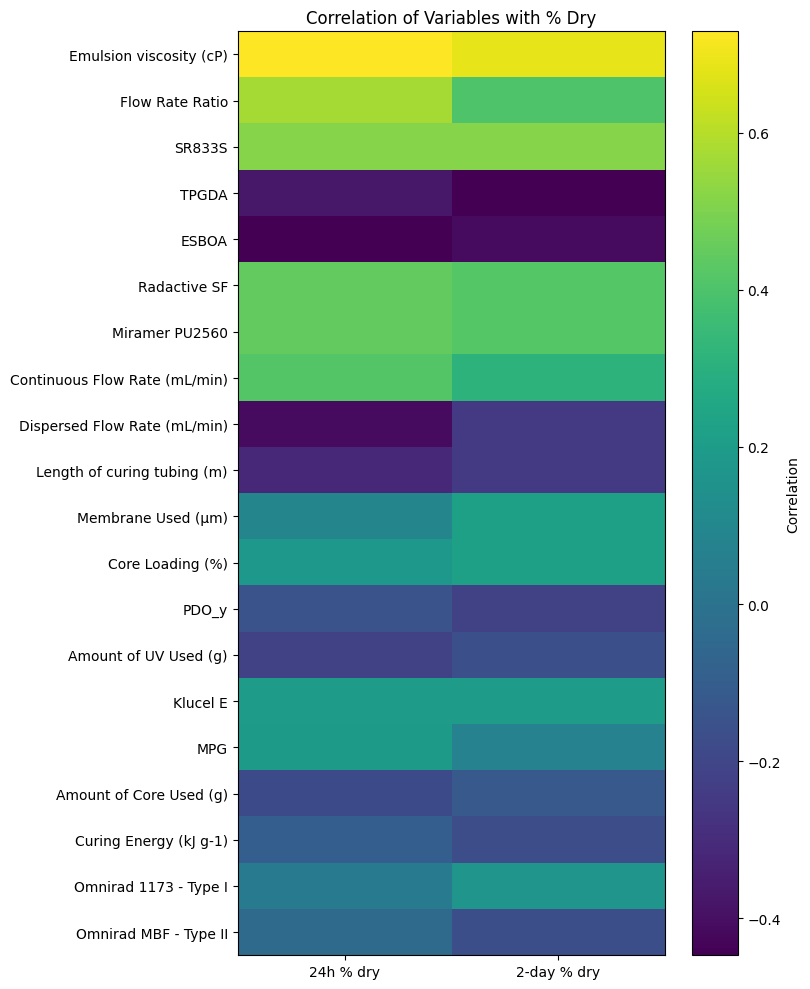

In [51]:
top_vars = corr_table.head(20).index.tolist()
heatmap_df = corr_table.loc[top_vars, ["Corr_with_24h_%dry", "Corr_with_2day_%dry"]]

plt.figure(figsize=(8, 10))
plt.imshow(heatmap_df.values, aspect="auto")
plt.xticks([0, 1], ["24h % dry", "2-day % dry"])
plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.colorbar(label="Correlation")
plt.title("Correlation of Variables with % Dry")
plt.tight_layout()
plt.show()

## Success rate plots for core and UV

These bar charts show which `Core used` and `UV used` values have the highest success rate.

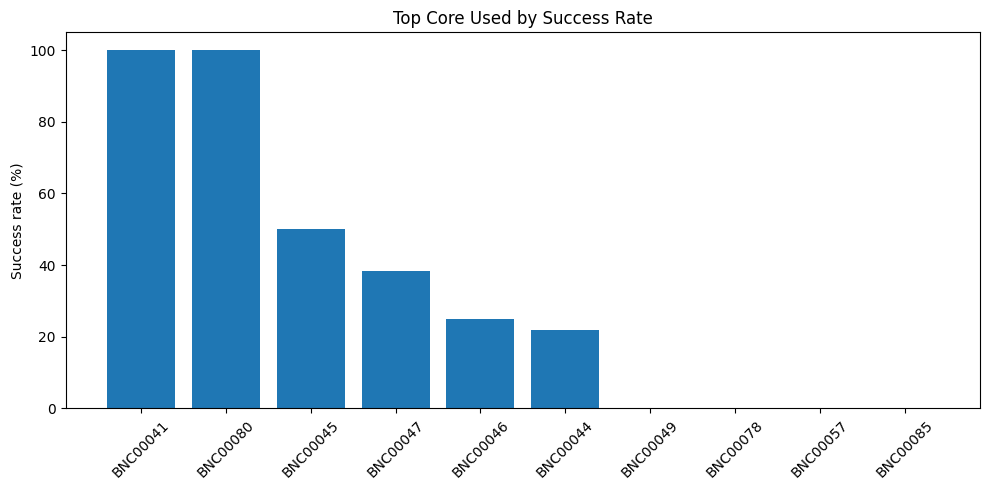

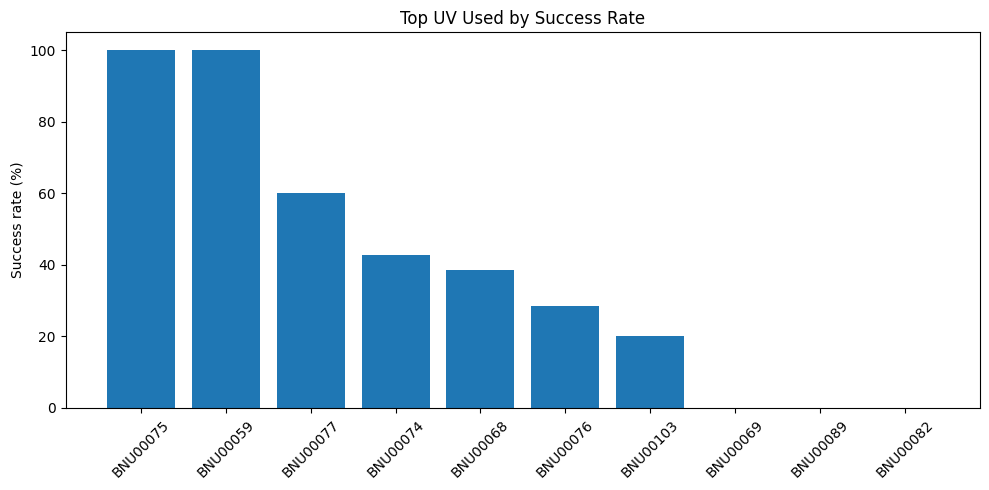

In [52]:
core_plot = core_summary.sort_values("success_rate_both", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(core_plot[core_col], core_plot["success_rate_both"])
plt.xticks(rotation=45)
plt.ylabel("Success rate (%)")
plt.title("Top Core Used by Success Rate")
plt.tight_layout()
plt.show()

uv_plot = uv_summary.sort_values("success_rate_both", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(uv_plot[uv_col], uv_plot["success_rate_both"])
plt.xticks(rotation=45)
plt.ylabel("Success rate (%)")
plt.title("Top UV Used by Success Rate")
plt.tight_layout()
plt.show()

## Scatter plots for strongest variables

These plots help show how the most strongly correlated variables behave against `% dry`.

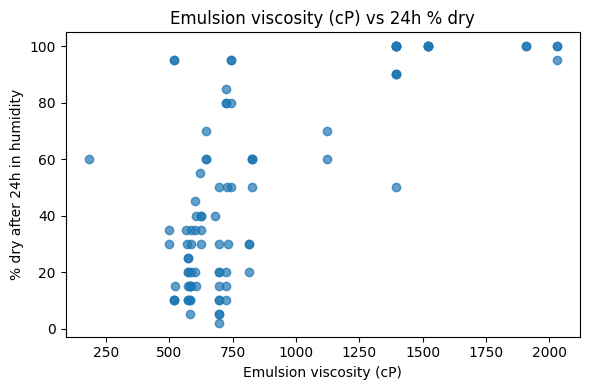

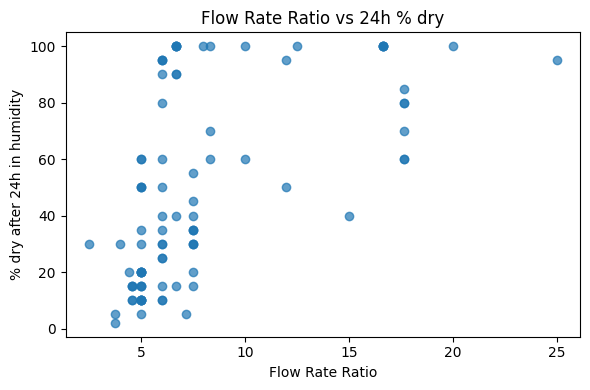

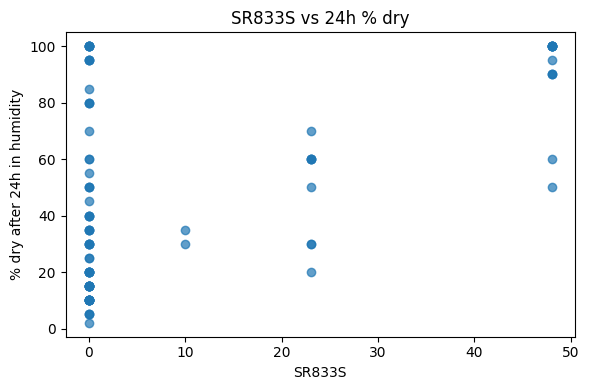

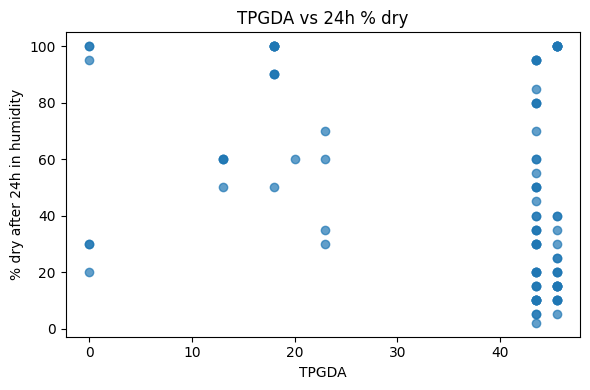

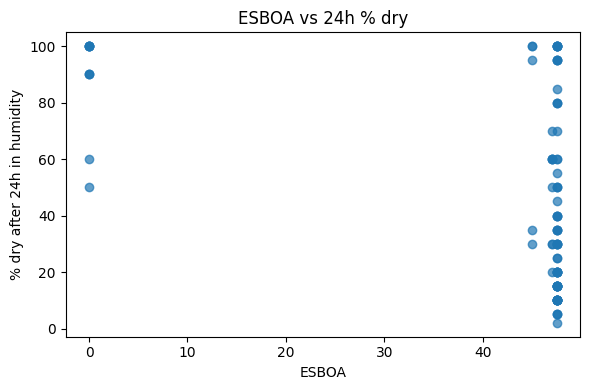

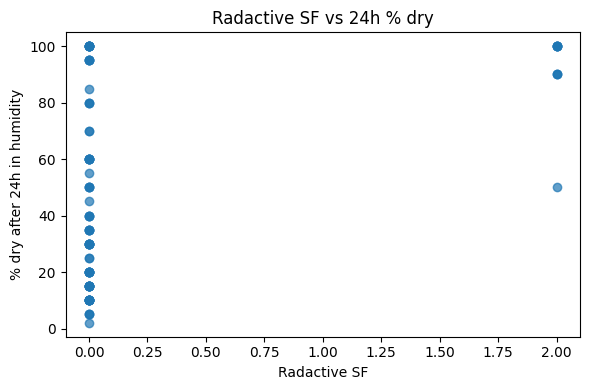

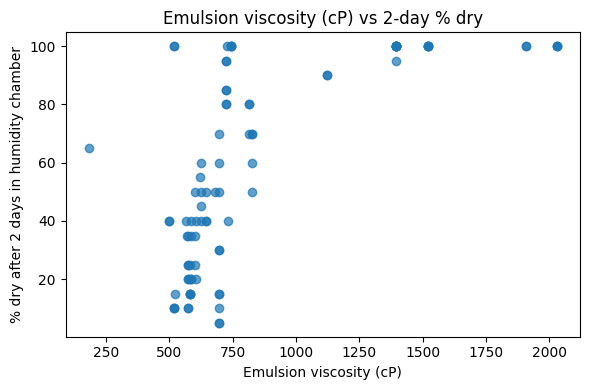

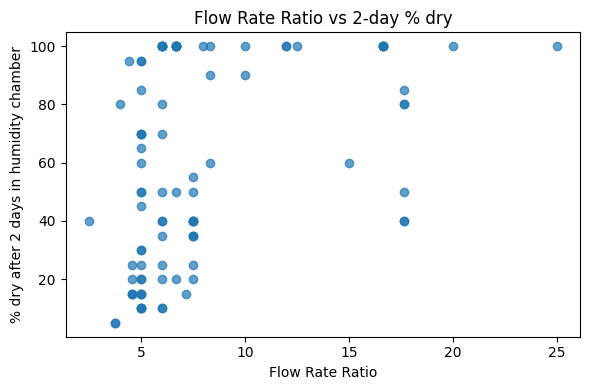

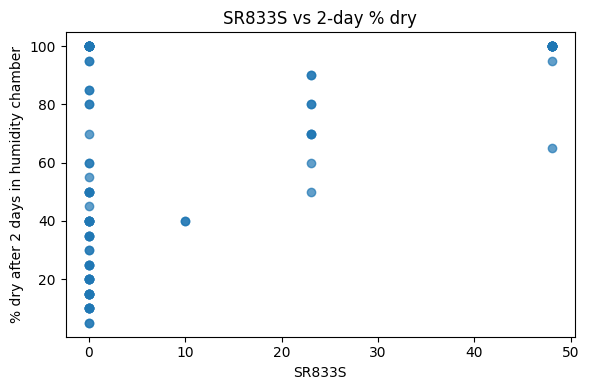

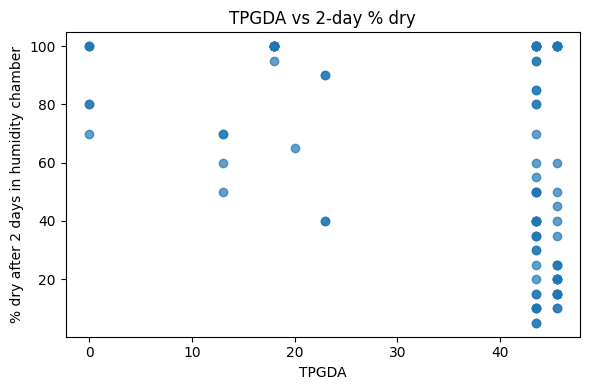

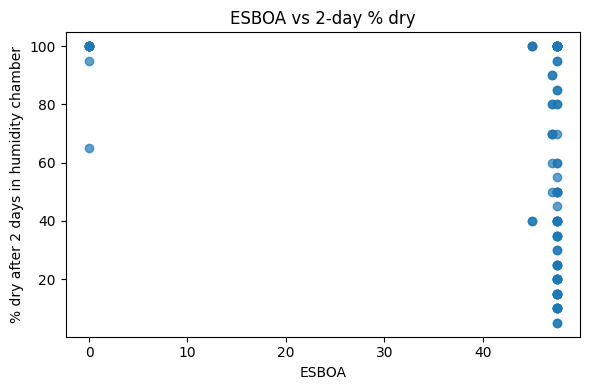

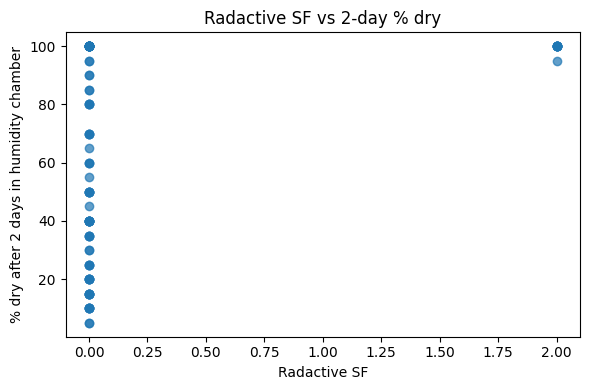

In [53]:
strongest_vars = corr_table.head(6).index.tolist()

for var in strongest_vars:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[var], df[dry_24_col], alpha=0.7)
    plt.xlabel(var)
    plt.ylabel(dry_24_col)
    plt.title(f"{var} vs 24h % dry")
    plt.tight_layout()
    plt.show()

for var in strongest_vars:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[var], df[dry_2d_col], alpha=0.7)
    plt.xlabel(var)
    plt.ylabel(dry_2d_col)
    plt.title(f"{var} vs 2-day % dry")
    plt.tight_layout()
    plt.show()

## Comparing successful vs unsuccessful batches

This section compares the mean values of formulation/process variables between successful and unsuccessful batches to identify what may contribute to better outcomes.

In [54]:
exclude_cols = {
    dry_24_col, dry_2d_col,
    "Amount of Core Used (g)",
    "Amount of UV Used (g)"
}

ingredient_candidates = [
    c for c in numeric_df.columns
    if c not in exclude_cols
]

success_means = df[df["Success_Both"]][ingredient_candidates].mean()
fail_means = df[~df["Success_Both"]][ingredient_candidates].mean()

ingredient_compare = pd.DataFrame({
    "Successful_mean": success_means,
    "Unsuccessful_mean": fail_means
})

ingredient_compare["Difference"] = ingredient_compare["Successful_mean"] - ingredient_compare["Unsuccessful_mean"]
ingredient_compare["Abs_Difference"] = ingredient_compare["Difference"].abs()
ingredient_compare = ingredient_compare.sort_values("Abs_Difference", ascending=False)

display(ingredient_compare.head(25))

,Successful_mean,Unsuccessful_mean,Difference,Abs_Difference
UV Power (J s-1),757.904762,2714.083333,-1956.178571,1956.178571
Mass of emulsion used / g,4600.000000,3694.736111,905.263889,905.263889
Emulsion viscosity (cP),596.990476,926.002778,-329.012302,329.012302
Impellor Speed (rpm),139.523810,91.375000,48.148810,48.148810
Continuous Flow Rate (mL/min),143.333333,178.958333,-35.625000,35.625000
SR833S,0.000000,12.486111,-12.486111,12.486111
TPGDA,44.642857,33.590278,11.052579,11.052579
Length of curing tubing (m),32.714286,23.800000,8.914286,8.914286
ESBOA,47.500000,40.006944,7.493056,7.493056
Glycerol,36.190476,30.083333,6.107143,6.107143


## Final interpretation

This section summarises the main findings from the exploration.

In [55]:
best_core = core_summary.iloc[0][core_col] if len(core_summary) > 0 else "N/A"
best_uv = uv_summary.iloc[0][uv_col] if len(uv_summary) > 0 else "N/A"

print("Best-performing core by success rate:", best_core)
print("Best-performing UV by success rate:", best_uv)

print("\nTop variables most linked to % dry:")
display(corr_table.head(10)[["Corr_with_24h_%dry", "Corr_with_2day_%dry"]])

Best-performing core by success rate: BNC00041
Best-performing UV by success rate: BNU00075

Top variables most linked to % dry:


,Corr_with_24h_%dry,Corr_with_2day_%dry
Emulsion viscosity (cP),0.729329,0.684038
Flow Rate Ratio,0.571739,0.404796
SR833S,0.514049,0.516026
TPGDA,-0.369636,-0.447311
ESBOA,-0.446748,-0.413859
Radactive SF,0.445912,0.417061
Miramer PU2560,0.445912,0.417061
Continuous Flow Rate (mL/min),0.416509,0.314473
Dispersed Flow Rate (mL/min),-0.412251,-0.247604
Length of curing tubing (m),-0.311940,-0.248179


# Modelling & Statistical Analysis

This section applies statistical models to understand:

- Which variables significantly influence `% dry`
- Whether formulation categories (Core, UV, formulations) differ significantly
- How well `% dry` can be predicted from process/formulation variables

Methods used:
- Simple Linear Regression
- Multiple Linear Regression
- ANOVA (Analysis of Variance)

In [56]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

## Simple Linear Regression

We test how individual variables relate to `% dry`.

Example:
- Emulsion viscosity vs % dry

In [57]:
# Example: Emulsion viscosity → % dry (24h)

x_var = "Emulsion viscosity (cP)"
y_var = "% dry after 24h in humidity"

df_clean = df[[x_var, y_var]].dropna()

X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]

model = sm.OLS(y, X).fit()

print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.532
Model:                                     OLS   Adj. R-squared:                  0.527
Method:                          Least Squares   F-statistic:                     103.4
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           1.13e-16
Time:                                 20:47:43   Log-Likelihood:                -424.08
No. Observations:                           93   AIC:                             852.2
Df Residuals:                               91   BIC:                             857.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

Other variables:

In [58]:

x_var = "Flow Rate Ratio"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())



                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.327
Model:                                     OLS   Adj. R-squared:                  0.319
Method:                          Least Squares   F-statistic:                     44.19
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           2.15e-09
Time:                                 20:47:43   Log-Likelihood:                -440.98
No. Observations:                           93   AIC:                             886.0
Df Residuals:                               91   BIC:                             891.0
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [59]:
x_var = "SR833S"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.264
Model:                                     OLS   Adj. R-squared:                  0.256
Method:                          Least Squares   F-statistic:                     32.68
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           1.36e-07
Time:                                 20:47:43   Log-Likelihood:                -445.11
No. Observations:                           93   AIC:                             894.2
Df Residuals:                               91   BIC:                             899.3
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [60]:

x_var = "TPGDA"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.137
Model:                                     OLS   Adj. R-squared:                  0.127
Method:                          Least Squares   F-statistic:                     14.40
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           0.000266
Time:                                 20:47:43   Log-Likelihood:                -452.55
No. Observations:                           93   AIC:                             909.1
Df Residuals:                               91   BIC:                             914.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [61]:

x_var = "ESBOA"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.200
Model:                                     OLS   Adj. R-squared:                  0.191
Method:                          Least Squares   F-statistic:                     22.69
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           7.16e-06
Time:                                 20:47:43   Log-Likelihood:                -449.03
No. Observations:                           93   AIC:                             902.1
Df Residuals:                               91   BIC:                             907.1
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [62]:

x_var = "Radactive SF"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.199
Model:                                     OLS   Adj. R-squared:                  0.190
Method:                          Least Squares   F-statistic:                     22.59
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           7.48e-06
Time:                                 20:47:43   Log-Likelihood:                -449.07
No. Observations:                           93   AIC:                             902.1
Df Residuals:                               91   BIC:                             907.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [63]:

x_var = "Miramer PU2560"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.199
Model:                                     OLS   Adj. R-squared:                  0.190
Method:                          Least Squares   F-statistic:                     22.59
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           7.48e-06
Time:                                 20:47:43   Log-Likelihood:                -449.07
No. Observations:                           93   AIC:                             902.1
Df Residuals:                               91   BIC:                             907.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [64]:

x_var = "Continuous Flow Rate (mL/min)"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.173
Model:                                     OLS   Adj. R-squared:                  0.164
Method:                          Least Squares   F-statistic:                     19.10
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           3.29e-05
Time:                                 20:47:43   Log-Likelihood:                -450.52
No. Observations:                           93   AIC:                             905.0
Df Residuals:                               91   BIC:                             910.1
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [65]:

x_var = "Dispersed Flow Rate (mL/min)"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.170
Model:                                     OLS   Adj. R-squared:                  0.161
Method:                          Least Squares   F-statistic:                     18.63
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           4.03e-05
Time:                                 20:47:43   Log-Likelihood:                -450.72
No. Observations:                           93   AIC:                             905.4
Df Residuals:                               91   BIC:                             910.5
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

In [66]:

x_var = "Length of curing tubing (m)"
y_var = "% dry after 24h in humidity"
df_clean = df[[x_var, y_var]].dropna()
X = sm.add_constant(df_clean[x_var])
y = df_clean[y_var]
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.097
Model:                                     OLS   Adj. R-squared:                  0.087
Method:                          Least Squares   F-statistic:                     9.809
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):            0.00234
Time:                                 20:47:43   Log-Likelihood:                -454.62
No. Observations:                           93   AIC:                             913.2
Df Residuals:                               91   BIC:                             918.3
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------

# Multivariate Analysis (Multiple Regression)

This section builds a multivariate model to explain `% dry` using:

- Process variables (flow rates, viscosity, etc.)
- Formulation variables (ingredients)
- Categorical variables (Core used, UV used, formulations)

This allows us to:
- identify the most important predictors
- control for multiple variables simultaneously
- determine statistically significant drivers of performance

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

## Choose target variables and selected predictors

These predictors are chosen based on the earlier correlation findings and domain relevance.

In [68]:
target_24 = "% dry after 24h in humidity"
target_2d = "% dry after 2 days in humidity chamber"

selected_predictors = [
    "Emulsion viscosity (cP)",
    "Flow Rate Ratio",
    "Continuous Flow Rate (mL/min)",
    "Dispersed Flow Rate (mL/min)",
    "TPGDA",
    "ESBOA"
]

categorical_predictors = [
    "Core used",
    "UV used",
    "Core_formulation",
    "UV_formulation",
    "Outer_formulation"
]

# keep only columns that actually exist
selected_predictors = [c for c in selected_predictors if c in df.columns]
categorical_predictors = [c for c in categorical_predictors if c in df.columns]

print("Numeric predictors:", selected_predictors)
print("Categorical predictors:", categorical_predictors)

Numeric predictors: ['Emulsion viscosity (cP)', 'Flow Rate Ratio', 'Continuous Flow Rate (mL/min)', 'Dispersed Flow Rate (mL/min)', 'TPGDA', 'ESBOA']
Categorical predictors: ['Core used', 'UV used', 'Core_formulation', 'UV_formulation', 'Outer_formulation']


## Build a clean modelling dataset

This keeps only the variables needed for the regression, encodes categories, and removes missing values only from the selected columns.

In [69]:
reg_df = df[[target_24, target_2d] + selected_predictors + categorical_predictors].copy()

# one-hot encode categoricals
if len(categorical_predictors) > 0:
    reg_df = pd.get_dummies(reg_df, columns=categorical_predictors, drop_first=True)

# convert boolean dummies to int
bool_cols = reg_df.select_dtypes(include=["bool"]).columns
if len(bool_cols) > 0:
    reg_df[bool_cols] = reg_df[bool_cols].astype(int)

# force numeric conversion
for col in reg_df.columns:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

# drop rows only for selected model columns
reg_df = reg_df.dropna()

print("Regression dataframe shape:", reg_df.shape)
display(reg_df.head())

if reg_df.shape[0] == 0:
    print("No rows left. Remove some predictors with missing values.")

Regression dataframe shape: (93, 65)


,% dry after 24h in humidity,% dry after 2 days in humidity chamber,Emulsion viscosity (cP),Flow Rate Ratio,Continuous Flow Rate (mL/min),Dispersed Flow Rate (mL/min),TPGDA,ESBOA,Core used_BNC00044,Core used_BNC00045,...,UV_formulation_AUF130,UV_formulation_AUF138,UV_formulation_AUF191,UV_formulation_AUF194,UV_formulation_AUF197,UV_formulation_AUF275,Outer_formulation_2.25/38M/7,Outer_formulation_2.25/38P/7,Outer_formulation_4.5/14.7M/4,Outer_formulation_4.5/14.7P/4
0,15.0,15.0,520.8,5.00,100.0,20.0,45.5,47.5,0,0,...,0,0,0,0,0,0,0,0,0,0
1,50.0,60.0,697.2,5.00,150.0,30.0,43.5,47.5,1,0,...,0,0,0,0,0,0,0,0,0,0
2,30.0,70.0,697.2,5.00,150.0,30.0,43.5,47.5,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2.0,5.0,697.2,3.75,150.0,40.0,43.5,47.5,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5.0,5.0,697.2,3.75,150.0,40.0,43.5,47.5,1,0,...,0,0,0,0,0,0,0,0,0,0


## Check missing values before modelling

This helps identify whether a particular predictor is removing too many rows.

In [70]:
check_df = df[[target_24, target_2d] + selected_predictors + categorical_predictors].copy()
missing_summary = check_df.isna().sum().sort_values(ascending=False)
display(missing_summary)

% dry after 24h in humidity               0
% dry after 2 days in humidity chamber    0
Emulsion viscosity (cP)                   0
Flow Rate Ratio                           0
Continuous Flow Rate (mL/min)             0
Dispersed Flow Rate (mL/min)              0
TPGDA                                     0
ESBOA                                     0
Core used                                 0
UV used                                   0
Core_formulation                          0
UV_formulation                            0
Outer_formulation                         0
dtype: int64

## Full multiple regression model for 24h % dry

In [71]:
X_24 = reg_df.drop(columns=[target_24, target_2d], errors="ignore")
y_24 = reg_df[target_24]

print("X_24 shape:", X_24.shape)
print("y_24 shape:", y_24.shape)

if len(X_24) > 0 and X_24.shape[1] > 0:
    X_24 = sm.add_constant(X_24)
    full_model_24 = sm.OLS(y_24, X_24).fit()
    print(full_model_24.summary())
else:
    print("Regression could not run because X_24 is empty.")

X_24 shape: (93, 63)
y_24 shape: (93,)
                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.933
Model:                                     OLS   Adj. R-squared:                  0.899
Method:                          Least Squares   F-statistic:                     27.38
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           1.47e-25
Time:                                 20:47:43   Log-Likelihood:                -333.72
No. Observations:                           93   AIC:                             731.4
Df Residuals:                               61   BIC:                             812.5
Df Model:                                   31                                         
Covariance Type:                     nonrobust                                         
                                    coef    std err          t      P>|t|      [0

## Significant predictors for 24h % dry

In [72]:
if "full_model_24" in locals():
    pvals_24 = full_model_24.pvalues.sort_values()
    significant_vars_24 = [v for v in pvals_24[pvals_24 < 0.05].index if v != "const"]

    print("Significant variables for 24h % dry:")
    print(significant_vars_24)
else:
    significant_vars_24 = []
    print("24h model was not created.")

Significant variables for 24h % dry:
['UV used_BNU00089', 'Emulsion viscosity (cP)', 'Core used_BNC00055', 'UV used_BNU00082', 'UV_formulation_AUF194', 'UV_formulation_AUF096', 'UV used_BNU00071', 'Core_formulation_RAD-C-0002', 'Core used_BNC00046', 'ESBOA', 'UV used_BNU00077', 'Core used_BNC00053', 'UV_formulation_AUF197', 'UV used_BNU00087', 'Dispersed Flow Rate (mL/min)', 'UV used_BNU00073', 'Core used_BNC00083', 'UV used_BNU00108', 'UV_formulation_AUF275', 'Core_formulation_RAD-C-0008', 'Core used_BNC00057', 'UV used_BNU00118', 'Core_formulation_RAD-C-0016', 'Core used_BNC00085']


## Reduced model for 24h % dry

In [73]:
if "full_model_24" in locals() and len(significant_vars_24) > 0:
    X_24_reduced = X_24[["const"] + significant_vars_24]
    reduced_model_24 = sm.OLS(y_24, X_24_reduced).fit()
    print(reduced_model_24.summary())
else:
    print("No reduced 24h model created.")

                                 OLS Regression Results                                
Dep. Variable:     % dry after 24h in humidity   R-squared:                       0.888
Model:                                     OLS   Adj. R-squared:                  0.868
Method:                          Least Squares   F-statistic:                     44.07
Date:                         Mon, 30 Mar 2026   Prob (F-statistic):           3.66e-31
Time:                                 20:47:43   Log-Likelihood:                -357.68
No. Observations:                           93   AIC:                             745.4
Df Residuals:                               78   BIC:                             783.3
Df Model:                                   14                                         
Covariance Type:                     nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

## VIF for the reduced 24h model

In [74]:
if "reduced_model_24" in locals():
    vif_df_24 = pd.DataFrame()
    vif_df_24["Variable"] = X_24_reduced.columns
    vif_df_24["VIF"] = [
        variance_inflation_factor(X_24_reduced.values, i)
        for i in range(X_24_reduced.shape[1])
    ]
    display(vif_df_24.sort_values("VIF", ascending=False))
else:
    print("No VIF calculated for 24h model.")

c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
1,UV used_BNU00089,inf
7,UV used_BNU00071,inf
3,Core used_BNC00055,inf
4,UV used_BNU00082,inf
5,UV_formulation_AUF194,inf
6,UV_formulation_AUF096,inf
14,UV used_BNU00087,inf
13,UV_formulation_AUF197,inf
12,Core used_BNC00053,inf
23,Core_formulation_RAD-C-0016,inf


## Diagnostics for the reduced 24h model

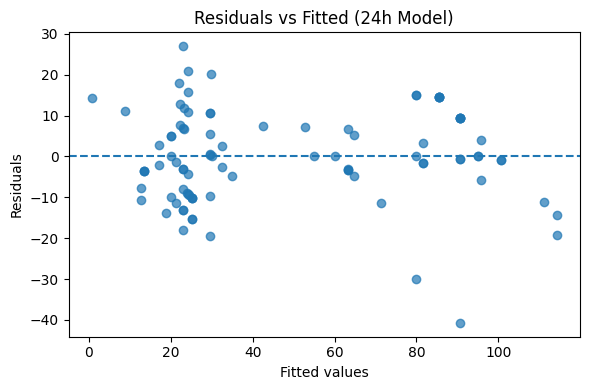

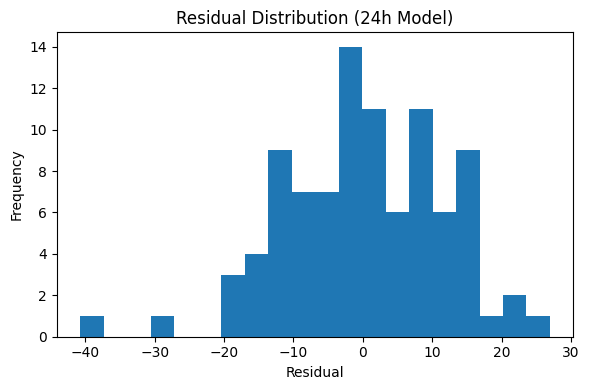

In [75]:
if "reduced_model_24" in locals():
    residuals_24 = reduced_model_24.resid
    fitted_24 = reduced_model_24.fittedvalues

    plt.figure(figsize=(6, 4))
    plt.scatter(fitted_24, residuals_24, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted (24h Model)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(residuals_24, bins=20)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution (24h Model)")
    plt.tight_layout()
    plt.show()
else:
    print("No 24h diagnostic plots available.")

## Full multiple regression model for 2-day % dry

In [76]:
X_2d = reg_df.drop(columns=[target_24, target_2d], errors="ignore")
y_2d = reg_df[target_2d]

print("X_2d shape:", X_2d.shape)
print("y_2d shape:", y_2d.shape)

if len(X_2d) > 0 and X_2d.shape[1] > 0:
    X_2d = sm.add_constant(X_2d)
    full_model_2d = sm.OLS(y_2d, X_2d).fit()
    print(full_model_2d.summary())
else:
    print("Regression could not run because X_2d is empty.")

X_2d shape: (93, 63)
y_2d shape: (93,)
                                      OLS Regression Results                                      
Dep. Variable:     % dry after 2 days in humidity chamber   R-squared:                       0.851
Model:                                                OLS   Adj. R-squared:                  0.775
Method:                                     Least Squares   F-statistic:                     11.24
Date:                                    Mon, 30 Mar 2026   Prob (F-statistic):           1.54e-15
Time:                                            20:47:43   Log-Likelihood:                -371.85
No. Observations:                                      93   AIC:                             807.7
Df Residuals:                                          61   BIC:                             888.7
Df Model:                                              31                                         
Covariance Type:                                nonrobust             

## Significant predictors for 2-day % dry

In [77]:
if "full_model_2d" in locals():
    pvals_2d = full_model_2d.pvalues.sort_values()
    significant_vars_2d = [v for v in pvals_2d[pvals_2d < 0.05].index if v != "const"]

    print("Significant variables for 2-day % dry:")
    print(significant_vars_2d)
else:
    significant_vars_2d = []
    print("2-day model was not created.")

Significant variables for 2-day % dry:
['UV used_BNU00089', 'Emulsion viscosity (cP)', 'UV_formulation_AUF096', 'UV used_BNU00071', 'Core used_BNC00055', 'UV_formulation_AUF191', 'UV used_BNU00081', 'UV_formulation_AUF113', 'UV used_BNU00072', 'Core_formulation_RAD-C-0008', 'Core used_BNC00057', 'Core used_BNC00046']


## Reduced model for 2-day % dry

In [78]:
if "full_model_2d" in locals() and len(significant_vars_2d) > 0:
    X_2d_reduced = X_2d[["const"] + significant_vars_2d]
    reduced_model_2d = sm.OLS(y_2d, X_2d_reduced).fit()
    print(reduced_model_2d.summary())
else:
    print("No reduced 2-day model created.")

                                      OLS Regression Results                                      
Dep. Variable:     % dry after 2 days in humidity chamber   R-squared:                       0.711
Model:                                                OLS   Adj. R-squared:                  0.688
Method:                                     Least Squares   F-statistic:                     29.93
Date:                                    Mon, 30 Mar 2026   Prob (F-statistic):           1.99e-20
Time:                                            20:47:43   Log-Likelihood:                -402.60
No. Observations:                                      93   AIC:                             821.2
Df Residuals:                                          85   BIC:                             841.5
Df Model:                                               7                                         
Covariance Type:                                nonrobust                                         
          

## VIF for the reduced 2-day model

In [79]:
if "reduced_model_2d" in locals():
    vif_df_2d = pd.DataFrame()
    vif_df_2d["Variable"] = X_2d_reduced.columns
    vif_df_2d["VIF"] = [
        variance_inflation_factor(X_2d_reduced.values, i)
        for i in range(X_2d_reduced.shape[1])
    ]
    display(vif_df_2d.sort_values("VIF", ascending=False))
else:
    print("No VIF calculated for 2-day model.")

c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variable,VIF
1,UV used_BNU00089,inf
4,UV used_BNU00071,inf
3,UV_formulation_AUF096,inf
6,UV_formulation_AUF191,inf
5,Core used_BNC00055,inf
9,UV used_BNU00072,inf
10,Core_formulation_RAD-C-0008,inf
7,UV used_BNU00081,inf
8,UV_formulation_AUF113,inf
11,Core used_BNC00057,inf


## Diagnostics for the reduced 2-day model

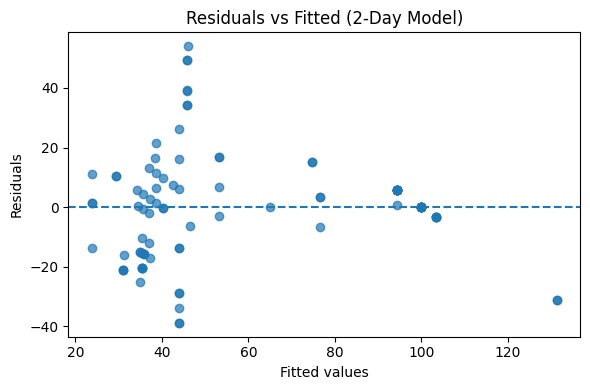

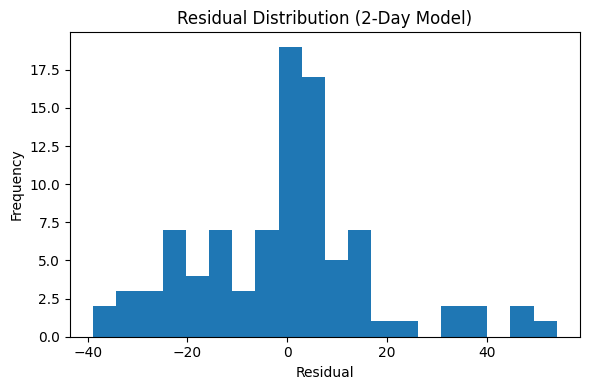

In [80]:
if "reduced_model_2d" in locals():
    residuals_2d = reduced_model_2d.resid
    fitted_2d = reduced_model_2d.fittedvalues

    plt.figure(figsize=(6, 4))
    plt.scatter(fitted_2d, residuals_2d, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Fitted (2-Day Model)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(residuals_2d, bins=20)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution (2-Day Model)")
    plt.tight_layout()
    plt.show()
else:
    print("No 2-day diagnostic plots available.")

## Summary of significant predictors

In [81]:
summary_rows = []

if "reduced_model_24" in locals():
    for var in significant_vars_24:
        summary_rows.append({
            "Model": "24h % dry",
            "Variable": var,
            "Coefficient": reduced_model_24.params[var],
            "p-value": reduced_model_24.pvalues[var]
        })

if "reduced_model_2d" in locals():
    for var in significant_vars_2d:
        summary_rows.append({
            "Model": "2-day % dry",
            "Variable": var,
            "Coefficient": reduced_model_2d.params[var],
            "p-value": reduced_model_2d.pvalues[var]
        })

summary_table = pd.DataFrame(summary_rows)

if len(summary_table) > 0:
    summary_table = summary_table.sort_values(["Model", "p-value"])
    display(summary_table)
else:
    print("No significant predictors found.")

,Model,Variable,Coefficient,p-value
25,2-day % dry,Emulsion viscosity (cP),0.072243,2.472165e-20
24,2-day % dry,UV used_BNU00089,38.212942,8.439373e-09
28,2-day % dry,Core used_BNC00055,30.907980,4.607393e-04
31,2-day % dry,UV_formulation_AUF113,-20.048145,3.410076e-03
32,2-day % dry,UV used_BNU00072,-20.048145,3.410076e-03
26,2-day % dry,UV_formulation_AUF096,29.153966,4.031241e-03
27,2-day % dry,UV used_BNU00071,29.153966,4.031241e-03
30,2-day % dry,UV used_BNU00081,12.100666,3.515743e-02
29,2-day % dry,UV_formulation_AUF191,12.100666,3.515743e-02
33,2-day % dry,Core_formulation_RAD-C-0008,7.304962,1.259479e-01


## Final interpretation

In [82]:
if "full_model_24" in locals():
    print("24h model R-squared:", round(full_model_24.rsquared, 4))
if "full_model_2d" in locals():
    print("2-day model R-squared:", round(full_model_2d.rsquared, 4))

if "reduced_model_24" in locals():
    print("\nSignificant predictors for 24h % dry:")
    for var in significant_vars_24:
        coef = reduced_model_24.params[var]
        direction = "increases" if coef > 0 else "decreases"
        print(f"- {var}: coefficient = {coef:.4f} ({direction} % dry)")

if "reduced_model_2d" in locals():
    print("\nSignificant predictors for 2-day % dry:")
    for var in significant_vars_2d:
        coef = reduced_model_2d.params[var]
        direction = "increases" if coef > 0 else "decreases"
        print(f"- {var}: coefficient = {coef:.4f} ({direction} % dry)")

24h model R-squared: 0.933
2-day model R-squared: 0.851

Significant predictors for 24h % dry:
- UV used_BNU00089: coefficient = 22.9451 (increases % dry)
- Emulsion viscosity (cP): coefficient = 0.0533 (increases % dry)
- Core used_BNC00055: coefficient = 9.7383 (increases % dry)
- UV used_BNU00082: coefficient = 11.3194 (increases % dry)
- UV_formulation_AUF194: coefficient = 11.3194 (increases % dry)
- UV_formulation_AUF096: coefficient = 17.0127 (increases % dry)
- UV used_BNU00071: coefficient = 17.0127 (increases % dry)
- Core_formulation_RAD-C-0002: coefficient = 43.7102 (increases % dry)
- Core used_BNC00046: coefficient = -50.4121 (decreases % dry)
- ESBOA: coefficient = -0.6400 (decreases % dry)
- UV used_BNU00077: coefficient = -5.4721 (decreases % dry)
- Core used_BNC00053: coefficient = 4.4393 (increases % dry)
- UV_formulation_AUF197: coefficient = 4.4393 (increases % dry)
- UV used_BNU00087: coefficient = 4.4393 (increases % dry)
- Dispersed Flow Rate (mL/min): coefficie

# ANOVA Analysis (Formulation Effects)

This section uses ANOVA (Analysis of Variance) to test whether categorical variables:

- Core used
- UV used
- Formulations

have a statistically significant effect on `% dry`.

Interpretation:
- p < 0.05 → significant effect
- p ≥ 0.05 → no significant effect

In [86]:
df_anova = df.rename(columns={
    "% dry after 24h in humidity": "dry_24h",
    "% dry after 2 days in humidity chamber": "dry_2d",
    "Core used": "Core_used",
    "UV used": "UV_used"
}).copy()

print("ANOVA dataframe shape:", df_anova.shape)
display(df_anova.head())

ANOVA dataframe shape: (93, 150)


,AXF Number,Core_used,Amount of Core Used (g),UV_used,Amount of UV Used (g),Emulsion viscosity (cP),Emulsion Gear Pump used,Single Emulsion (SE) Number,Vessel Used,Impellor Used,...,NaCl_y,Glycerol,PDO_y,MPG,Sugar,PVA (10% in water),Outer_water,Success_24h,Success_2days,Success_Both
0,AXF0119,BNC00041,1500.0,BNU00059,3500.0,520.8,P23,SE014,5L Jug,Impellorpellor,...,7,38,0.0,0.0,0,2.25,52.75,True,True,True
1,AXF0128,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,7,38,0.0,0.0,0,2.25,52.75,False,False,False
2,AXF0129,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,7,38,0.0,0.0,0,2.25,52.75,False,False,False
3,AXF0130,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,7,38,0.0,0.0,0,2.25,52.75,True,True,True
4,AXF0130,BNC00044,1500.0,BNU00068,3500.0,697.2,P23,SE015,5L Jug,Impellorpellor,...,7,38,0.0,0.0,0,2.25,52.75,True,True,True


## ANOVA: Core used → % dry (24h)

In [87]:
anova_core = smf.ols('dry_24h ~ C(Core_used)', data=df_anova).fit()
core_results = sm.stats.anova_lm(anova_core, typ=2)

display(core_results)

p_core = core_results["PR(>F)"].iloc[0]

print("\nInterpretation:")
if p_core < 0.05:
    print("Core used has a statistically significant effect on 24h % dry.")
else:
    print("Core used does not have a statistically significant effect on 24h % dry.")

,sum_sq,df,F,PR(>F)
C(Core_used),27052.115256,16.0,1.621693,0.083332
Residual,79236.680443,76.0,NaN,NaN



Interpretation:
Core used does not have a statistically significant effect on 24h % dry.


## ANOVA: UV used → % dry (24h)

In [88]:
anova_uv = smf.ols('dry_24h ~ C(UV_used)', data=df_anova).fit()
uv_results = sm.stats.anova_lm(anova_uv, typ=2)

display(uv_results)

p_uv = uv_results["PR(>F)"].iloc[0]

print("\nInterpretation:")
if p_uv < 0.05:
    print("UV used has a statistically significant effect on 24h % dry.")
else:
    print("UV used does not have a statistically significant effect on 24h % dry.")

,sum_sq,df,F,PR(>F)
C(UV_used),79396.550278,22.0,9.393986,2.450147e-13
Residual,26892.245421,70.0,NaN,NaN



Interpretation:
UV used has a statistically significant effect on 24h % dry.


## ANOVA: Formulations → % dry (24h)

In [89]:
formulation_cols = [
    "Core_formulation",
    "UV_formulation",
    "Outer_formulation"
]

for col in formulation_cols:
    if col in df_anova.columns:
        print(f"\n=== ANOVA for {col} ===")
        
        model = smf.ols(f'dry_24h ~ C({col})', data=df_anova).fit()
        results = sm.stats.anova_lm(model, typ=2)
        
        display(results)
        
        p_val = results["PR(>F)"].iloc[0]
        if p_val < 0.05:
            print(f"{col} has a statistically significant effect on 24h % dry.")
        else:
            print(f"{col} does not have a statistically significant effect on 24h % dry.")


=== ANOVA for Core_formulation ===


,sum_sq,df,F,PR(>F)
C(Core_formulation),7061.478882,6.0,1.020027,0.41785
Residual,99227.316817,86.0,NaN,NaN


Core_formulation does not have a statistically significant effect on 24h % dry.

=== ANOVA for UV_formulation ===


,sum_sq,df,F,PR(>F)
C(UV_formulation),34169.266069,9.0,4.369365,0.00011
Residual,72119.529630,83.0,NaN,NaN


UV_formulation has a statistically significant effect on 24h % dry.

=== ANOVA for Outer_formulation ===


,sum_sq,df,F,PR(>F)
C(Outer_formulation),6027.526218,4.0,1.3226,0.267844
Residual,100261.269481,88.0,NaN,NaN


Outer_formulation does not have a statistically significant effect on 24h % dry.


## Two-way ANOVA: Core × UV interaction

This tests whether the effect of UV depends on the Core used.

In [90]:
anova_interaction = smf.ols(
    'dry_24h ~ C(Core_used) * C(UV_used)',
    data=df_anova
).fit()

interaction_results = sm.stats.anova_lm(anova_interaction, typ=2)

display(interaction_results)

p_core_main = interaction_results["PR(>F)"].iloc[0]
p_uv_main = interaction_results["PR(>F)"].iloc[1]
p_interaction = interaction_results["PR(>F)"].iloc[2]

print("\nInterpretation:")

if p_core_main < 0.05:
    print("Core used has a significant main effect.")
else:
    print("Core used does not have a significant main effect.")

if p_uv_main < 0.05:
    print("UV used has a significant main effect.")
else:
    print("UV used does not have a significant main effect.")

if p_interaction < 0.05:
    print("There is a significant interaction between Core used and UV used.")
else:
    print("There is no significant interaction between Core used and UV used.")

c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 16, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 22, but rank is 2
  warnings.warn('covariance of constraints does not have full '
c:\Users\amirh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 352, but rank is 25
  warnings.warn('covariance of constraints does not h

,sum_sq,df,F,PR(>F)
C(Core_used),NaN,16.0,NaN,NaN
C(UV_used),5.995719e+03,22.0,0.694164,5.030478e-01
C(Core_used):C(UV_used),1.126178e+06,352.0,8.149069,3.565560e-12
Residual,2.630457e+04,67.0,NaN,NaN



Interpretation:
Core used does not have a significant main effect.
UV used does not have a significant main effect.
There is a significant interaction between Core used and UV used.


## ANOVA: Core used → 2-day % dry

In [91]:
anova_core_2d = smf.ols('dry_2d ~ C(Core_used)', data=df_anova).fit()
core_2d_results = sm.stats.anova_lm(anova_core_2d, typ=2)

display(core_2d_results)

p_core_2d = core_2d_results["PR(>F)"].iloc[0]

print("\nInterpretation:")
if p_core_2d < 0.05:
    print("Core used has a statistically significant effect on 2-day % dry.")
else:
    print("Core used does not have a statistically significant effect on 2-day % dry.")

,sum_sq,df,F,PR(>F)
C(Core_used),36726.622215,16.0,2.427242,0.005253
Residual,71872.302516,76.0,NaN,NaN



Interpretation:
Core used has a statistically significant effect on 2-day % dry.


## Summary of ANOVA findings

In [92]:
anova_summary = pd.DataFrame([
    {
        "Test": "Core used → 24h % dry",
        "p-value": p_core,
        "Significant (<0.05)": p_core < 0.05
    },
    {
        "Test": "UV used → 24h % dry",
        "p-value": p_uv,
        "Significant (<0.05)": p_uv < 0.05
    },
    {
        "Test": "Core used × UV used interaction → 24h % dry",
        "p-value": p_interaction,
        "Significant (<0.05)": p_interaction < 0.05
    },
    {
        "Test": "Core used → 2-day % dry",
        "p-value": p_core_2d,
        "Significant (<0.05)": p_core_2d < 0.05
    }
])

display(anova_summary)

,Test,p-value,Significant (<0.05)
0,Core used → 24h % dry,8.333244e-02,False
1,UV used → 24h % dry,2.450147e-13,True
2,Core used × UV used interaction → 24h % dry,3.565560e-12,True
3,Core used → 2-day % dry,5.253153e-03,True
